In [ ]:
import scanpy as sc

from train_integrate import train_integration
import st_datasets as stds

# load data
# 指定想要获取数据的 section_id
ids = ['151670', '151777']
#ids = [7,12]#第8张和最后一张


adata_list = [stds.get_data(stds.get_dlpfc_data, id=id)[0] for id in ids]
print (adata_list)
#adata_list = [stds.get_data(stds.get_dlpfc_data, id=i)[0] for i in range(4)]
#print (adata_list)
adatas = sc.concat(adata_list, label='batch')
print(adatas)
adatas = adatas[:, adata_list[-1].var['highly_variable']]
print(adatas)
# train SPAIR
adatas = train_integration(adata=adatas, radius=2)

>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151670, size: (3498, 33538), cluster: 6.(0.472s)
>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151777, size: (1275, 33538), cluster: 6.(0.227s)
[AnnData object with n_obs × n_vars = 3498 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial', AnnData object with n_obs × n_vars = 1275 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial']
AnnData object with n_obs × n_vars = 4773 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'batch'
  

  0%|          | 0/200 [00:00<?, ?it/s]

>>> INFO: Finish finding mmn pairs, find 61295 mnn node pairs(0.207s)!


 50%|█████     | 100/200 [00:59<00:57,  1.74it/s]

>>> INFO: Finish finding mmn pairs, find 85804 mnn node pairs(0.271s)!


100%|██████████| 200/200 [02:00<00:00,  1.67it/s]


In [2]:
adata = stds.cl.mclust_R(adatas, used_obsm='embedding', num_cluster=6)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [3]:
adata.write('DLPFC_151508_07_1.h5ad', compression='gzip')

In [3]:
adata.write('DLPFC_151509_07_1.h5ad', compression='gzip')

In [3]:
adata.write('DLPFC_151510_07_1.h5ad', compression='gzip')

In [3]:
adata.write('DLPFC_151669_7_1.h5ad', compression='gzip')

In [3]:
adata.write('DLPFC_151670_7_1.h5ad', compression='gzip')

In [ ]:
import scanpy as sc

from SPAIR.utils import coor_transform, plotting
from SPAIR.alignment import get_transform,calculate_alignment_score#,get_transform1


adatas = sc.read_h5ad('D:/biancheng/SPAIR-master/DLPFC_151670_7_1.h5ad')
adata_list = []
for i in range(2):
    adata_list.append(adatas[str(i) == adatas.obs['batch']])

[[1.0168e+04 4.4530e+03 9.6280e+03 ... 5.2100e+03 5.0080e+03 6.6700e+03]
 [8.5710e+03 9.6350e+03 4.2580e+03 ... 9.7570e+03 7.9600e+03 3.4130e+03]
 [1.0000e+00 1.0000e+00 1.0000e+00 ... 1.0000e+00 1.0000e+00 1.0000e+00]]
['Layer_4' 'Layer_6' 'Layer_3' ... 'Layer_6' 'Layer_5' 'Layer_3']
0.577472841623785


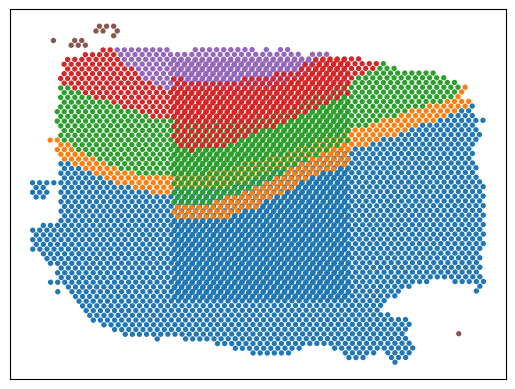

In [7]:
coor_list = [coor_transform(adata_list[src_id].obsm['spatial'], M[src_id]) for src_id in src_id_list]
label_list = [adata_list[src_id].obs['cluster'].to_numpy() for src_id in src_id_list]
print(coor_list[0])
print(label_list[0])

plotting(coor_list, label_list, spot_size=8)
score= calculate_alignment_score(coor_list, label_list, knears=1)
print (score)

In [ ]:
import numpy as np
from scipy.spatial import cKDTree
def evaluation(src_cor, tgt_cor, src_exp, tgt_exp, src_cell_type, tgt_cell_type):
    kd_tree = cKDTree(src_cor)
    distances, indices = kd_tree.query(tgt_cor, k=1)
    if hasattr(src_exp, 'toarray'):
        src_exp = src_exp.toarray()
    if hasattr(tgt_exp, 'toarray'):
        tgt_exp = tgt_exp.toarray()
    
    cell_pcc_values = []
    
   
    for i in range(tgt_exp.shape[0]):
       
        tgt_vector = tgt_exp[i, :]
        src_vector = src_exp[indices[i], :]
        
       
        pcc = np.corrcoef(tgt_vector, src_vector)[0, 1]
        
        
        cell_pcc_values.append(pcc)
    
    
    pcc_median = np.median(cell_pcc_values)
    
    
    cri = np.mean((tgt_cell_type == src_cell_type[indices]) + 0)
    
    return cell_pcc_values, pcc_median, cri

In [10]:
cell_pcc_values, pcc_median, cri=evaluation(coor_list[0].T, coor_list[1].T, adatas[str(0) == adatas.obs['batch']].X, adatas[str(1) == adatas.obs['batch']].X, np.array(label_list[0]), np.array(label_list[1]))

In [ ]:
#151508
cri

0.8601134215500945

In [52]:
#151509
cri

0.6871455576559546

In [21]:
#151510
cri

0.7117202268431002

In [8]:
#151669
cri

0.8117647058823529

In [11]:
#151670
cri

0.7349019607843137

In [ ]:
import scanpy as sc

from train_integrate import train_integration
import st_datasets as stds

# load data
# 指定想要获取数据的 section_id
ids = ['151671', '151672']



adata_list = [stds.get_data(stds.get_dlpfc_data, id=id)[0] for id in ids]
print (adata_list)
#adata_list = [stds.get_data(stds.get_dlpfc_data, id=i)[0] for i in range(4)]
#print (adata_list)
adatas = sc.concat(adata_list, label='batch')
print(adatas)
#adatas = adatas[:, adata_list[-1].var['highly_variable']]
print(adatas)
# train SPAIR
adatas = train_integration(adata=adatas, radius=2)

>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151671, size: (4110, 33538), cluster: 6.(0.612s)
>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151672, size: (4015, 33538), cluster: 6.(0.552s)
[AnnData object with n_obs × n_vars = 4110 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial', AnnData object with n_obs × n_vars = 4015 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial']
AnnData object with n_obs × n_vars = 8125 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'batch'
  

  0%|          | 0/200 [00:00<?, ?it/s]

>>> INFO: Finish finding mmn pairs, find 147425 mnn node pairs(0.501s)!


 50%|█████     | 100/200 [12:18<12:15,  7.36s/it]

>>> INFO: Finish finding mmn pairs, find 257573 mnn node pairs(0.664s)!


100%|██████████| 200/200 [23:46<00:00,  7.13s/it]


In [2]:
adata = stds.cl.mclust_R(adatas, used_obsm='embedding', num_cluster=6)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [3]:
adata.write('DLPFC_151671_72.h5ad', compression='gzip')

In [ ]:
import scanpy as sc
adata=sc.read_h5ad('D:/biancheng/SPAIR-master/DLPFC_151671_72.h5ad')

In [5]:
adata1 = adata[adata.obs['batch'] == '0']

In [6]:
adata2 = adata[adata.obs['batch'] == '1']

In [13]:
adata1.obs

,in_tissue,array_row,array_col,cluster,batch,mclust
AAACAAGTATCTCCCA-1,1,50,102,Layer_5,0,2
AAACACCAATAACTGC-1,1,59,19,Layer_6,0,5
AAACAGAGCGACTCCT-1,1,14,94,Layer_3,0,4
AAACAGCTTTCAGAAG-1,1,43,9,Layer_5,0,2
AAACAGGGTCTATATT-1,1,47,13,Layer_5,0,2
...,...,...,...,...,...,...
TTGTTTCACATCCAGG-1,1,58,42,Layer_6,0,5
TTGTTTCATTAGTCTA-1,1,60,30,Layer_6,0,5
TTGTTTCCATACAACT-1,1,45,27,Layer_5,0,2
TTGTTTGTATTACACG-1,1,73,41,WM,0,6


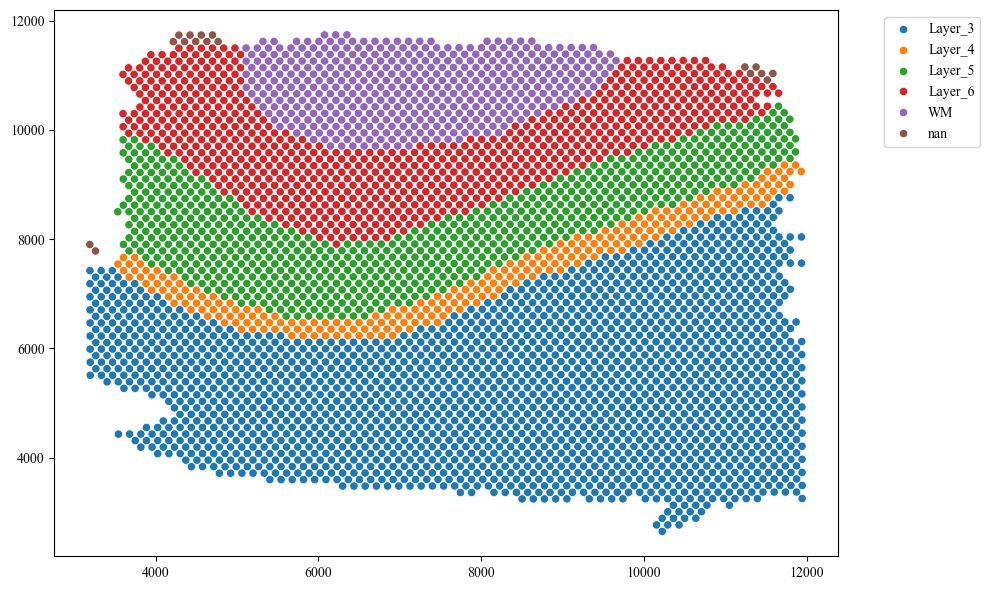

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns


spatial_coords = adata1.obsm['spatial']
    
    
cluster_labels = adata1.obs['cluster']
    
    
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    x=spatial_coords[:, 0],
    y=spatial_coords[:, 1],
    hue=cluster_labels,
        
    #s=50,               
    #alpha=1          
)
    
  
    
    
plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left')
    
    
plt.tight_layout()
plt.show()
    

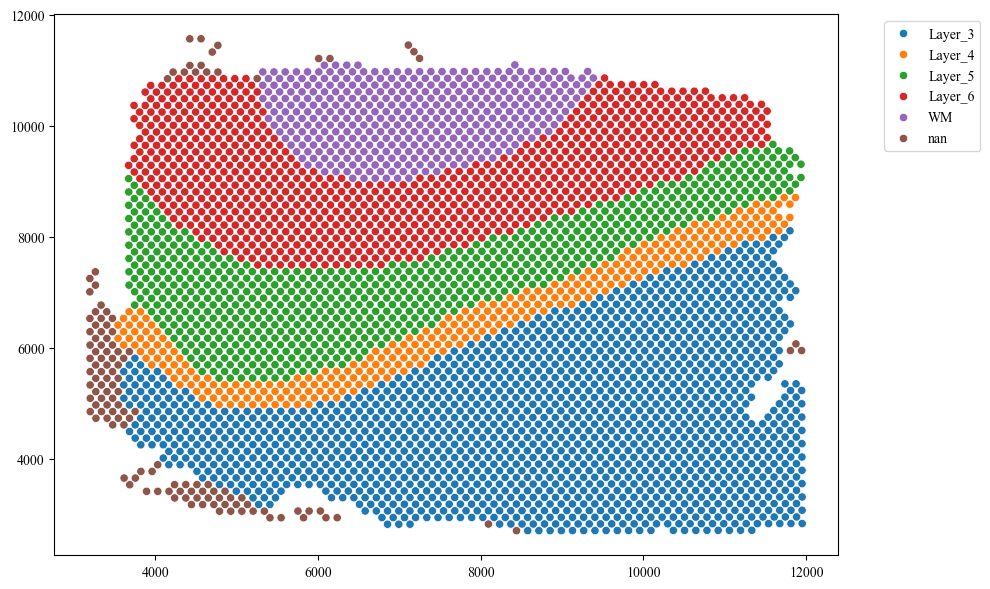

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns


spatial_coords = adata2.obsm['spatial']
    
    
cluster_labels = adata2.obs['cluster']
    
    
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    x=spatial_coords[:, 0],
    y=spatial_coords[:, 1],
    hue=cluster_labels,
        
    #s=50,               
    #alpha=1           
)
    
  
    
   
plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left')
    
    
plt.tight_layout()
plt.show()
    

In [ ]:
import scanpy as sc
adata3=sc.read_h5ad('C:/Users/kaiyueZhang/data/DLPFC/DLPFC_151777.h5ad')

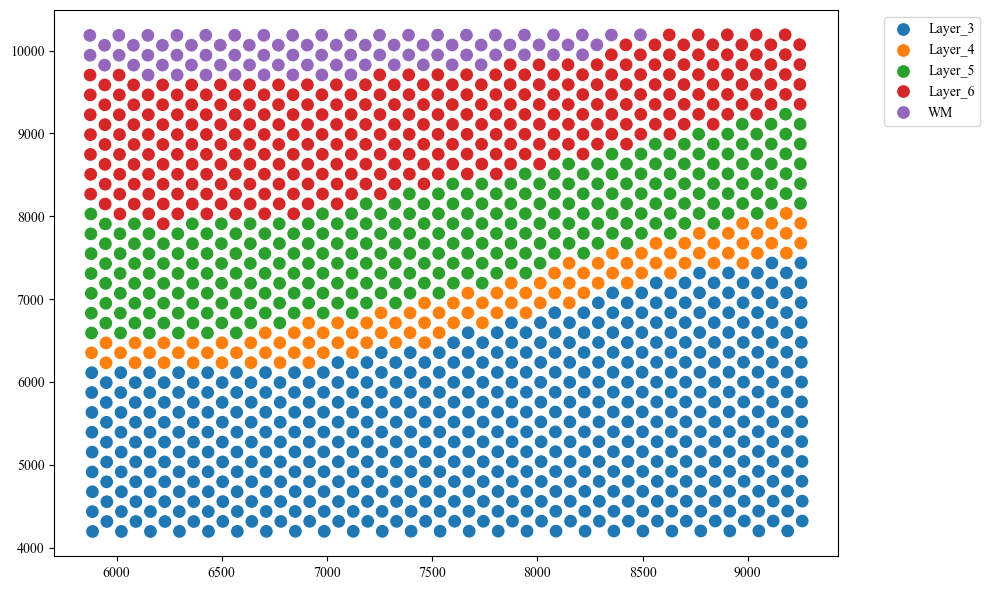

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns


spatial_coords = adata3.obsm['spatial']
    
    
cluster_labels = adata3.obs['cluster']
    
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    x=spatial_coords[:, 0],
    y=spatial_coords[:, 1],
    hue=cluster_labels,
        
    s=100,              
    #alpha=1           
)
    
  
    
    
plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left')
    
    
plt.tight_layout()
plt.show()
    

In [ ]:
import scanpy as sc

from SPAIR.utils import coor_transform, plotting
from SPAIR.alignment import get_transform,calculate_alignment_score#,get_transform1


adatas = sc.read_h5ad('D:/biancheng/SPAIR-master/DLPFC_151671_72.h5ad')
adata_list = []
for i in range(2):
    adata_list.append(adatas[str(i) == adatas.obs['batch']])

>>> INFO: dst slice id: 0, src slice id: 1
>>> INFO: dst coordination shape: (1745, 2)
>>> INFO: src coordination shape: (1620, 2)
0
1
2
3
4
>>> INFO: current distance: 81.64515126988366


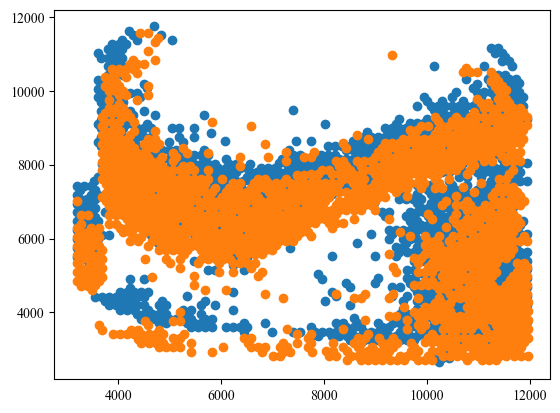

{0: array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 1: array([[ 1.00000000e+00,  2.07482676e-17,  4.22371644e+00],
        [ 1.00205164e-16,  1.00000000e+00, -5.61460621e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])}

In [25]:
dst_id = 0
pyramidal_label_id = [1,2]
src_id_list = list(range(0, 2))

M = get_transform(adata_list, dst_id, src_id_list, pyramidal_label_id,tolerance=1e-3,threshold=100)
M

[[1.0214e+04 4.4970e+03 9.6720e+03 ... 5.0520e+03 6.0090e+03 6.7130e+03]
 [8.6360e+03 9.7020e+03 4.3220e+03 ... 8.0260e+03 1.1383e+04 3.4780e+03]
 [1.0000e+00 1.0000e+00 1.0000e+00 ... 1.0000e+00 1.0000e+00 1.0000e+00]]
['Layer_5' 'Layer_6' 'Layer_3' ... 'Layer_5' 'WM' 'Layer_3']
0.4936739659367397


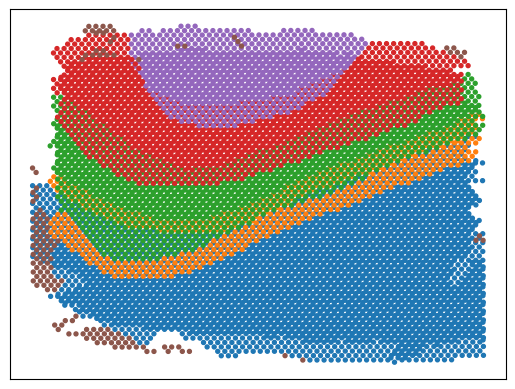

In [31]:
coor_list = [coor_transform(adata_list[src_id].obsm['spatial'], M[src_id]) for src_id in src_id_list]
label_list = [adata_list[src_id].obs['cluster'].to_numpy() for src_id in src_id_list]
print(coor_list[0])
print(label_list[0])

plotting(coor_list, label_list, spot_size=8)
score= calculate_alignment_score(coor_list, label_list, knears=1)
print (score)

In [ ]:
import numpy as np
from scipy.spatial import cKDTree
def evaluation(src_cor, tgt_cor, src_exp, tgt_exp, src_cell_type, tgt_cell_type):
    kd_tree = cKDTree(src_cor)
    distances, indices = kd_tree.query(tgt_cor, k=1)
    if hasattr(src_exp, 'toarray'):
        src_exp = src_exp.toarray()
    if hasattr(tgt_exp, 'toarray'):
        tgt_exp = tgt_exp.toarray()
   
    cell_pcc_values = []
    
    
    for i in range(tgt_exp.shape[0]):
        
        tgt_vector = tgt_exp[i, :]
        src_vector = src_exp[indices[i], :]
        
        
        pcc = np.corrcoef(tgt_vector, src_vector)[0, 1]
        
        
        cell_pcc_values.append(pcc)
    
 
    pcc_median = np.median(cell_pcc_values)
    
   
    cri = np.mean((tgt_cell_type == src_cell_type[indices]) + 0)
    
    return cell_pcc_values, pcc_median, cri

In [35]:
adatas[str(0) == adatas.obs['batch']].X.shape

(4110, 33538)

In [32]:
cell_pcc_values, pcc_median, cri=evaluation(coor_list[0].T, coor_list[1].T, adatas[str(0) == adatas.obs['batch']].X, adatas[str(1) == adatas.obs['batch']].X, np.array(label_list[0]), np.array(label_list[1]))

In [33]:
pcc_median

0.4770877673257203

In [34]:
cri

0.6488169364881694

AttributeError: module 'matplotlib.pyplot' has no attribute 'collections'

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

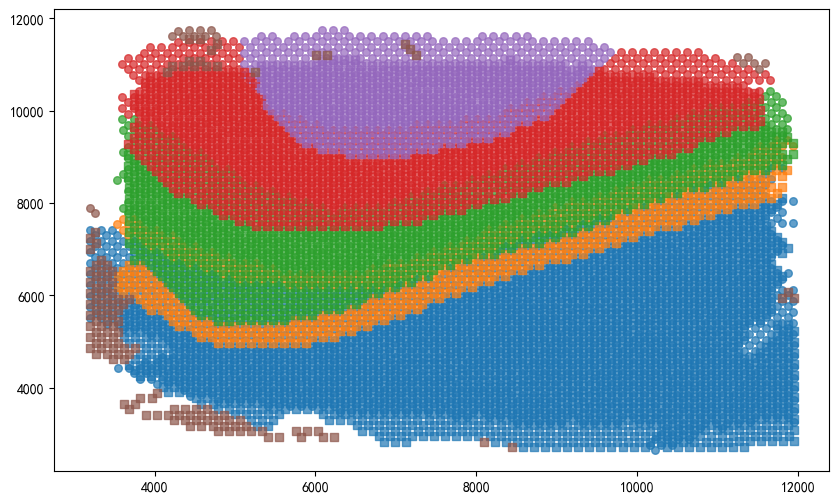

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams['axes.unicode_minus'] = False

def visualize_two_slices(coor_list, label_list, title="双切片对齐结果可视化"):
    src_coor, tgt_coor = coor_list
    src_labels, tgt_labels = label_list
    
    
    assert len(src_coor) == len(src_labels), "切片1坐标与标签长度不一致"
    assert len(tgt_coor) == len(tgt_labels), "切片2坐标与标签长度不一致"
    
    
    all_labels = np.unique(np.concatenate([src_labels, tgt_labels]))
    colors = list(mcolors.TABLEAU_COLORS.values())
    label_color_map = {label: colors[i % len(colors)] for i, label in enumerate(all_labels)}
    
    plt.figure(figsize=(10, 6))
    
    
    for label in np.unique(src_labels):
        mask = src_labels == label
        plt.scatter(
            src_coor[mask, 0], src_coor[mask, 1],
            c=label_color_map[label],
            marker='o',
            s=30,
            alpha=0.7,
            label=f'切片1 - {label}'  # 标签格式："切片X - 细胞类型"
        )
    
    
    for label in np.unique(tgt_labels):
        mask = tgt_labels == label
        plt.scatter(
            tgt_coor[mask, 0], tgt_coor[mask, 1],
            c=label_color_map[label],
            marker='s',
            s=30,
            alpha=0.7,
            label=f'切片2 - {label}'  # 标签格式："切片X - 细胞类型"
        )
  
    legend_handles = []
    seen_labels = set()  
    
    for handle in plt.gca().get_children():
        if isinstance(handle, plt.collections.PathCollection):
            label = handle.get_label()
            if not label:
                continue
            
            cell_type = label.split(' - ')[-1]
            
            if cell_type not in seen_labels:
                
                legend_handles.append(handle)
                seen_labels.add(cell_type)
    
    
    plt.legend(
        handles=legend_handles,
        loc='upper right',
        bbox_to_anchor=(1.2, 1),
        title='细胞类型', 
        fontsize=10,
        framealpha=0.9
    )
    
    
    plt.title(title, fontsize=16)
    plt.xlabel('X 坐标', fontsize=14)
    plt.ylabel('Y 坐标', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axis('equal')
    plt.tight_layout()
    
    return plt.gcf()

coor_list = [
    adata_list[0].obsm['spatial'],
    adata_list[1].obsm['spatial']
]
label_list = [
    adata_list[0].obs['cluster'].to_numpy(),
    adata_list[1].obs['cluster'].to_numpy()
]


fig = visualize_two_slices(coor_list, label_list, title='')
plt.show()

In [ ]:
import scanpy as sc

from SPAIR.utils import coor_transform, plotting
from SPAIR.alignment import get_transform,calculate_alignment_score#,get_transform1


adatas = sc.read_h5ad('D:/biancheng/SPAIR-master/DLP_8_7_7_7qu_zhongjian_500.h5ad')
adata_list = []
for i in range(2):
    adata_list.append(adatas[str(i) == adatas.obs['batch']])

>>> INFO: dst slice id: 0, src slice id: 1
>>> INFO: dst coordination shape: (1904, 2)
>>> INFO: src coordination shape: (545, 2)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
>>> INFO: current distance: 75.06273732016328


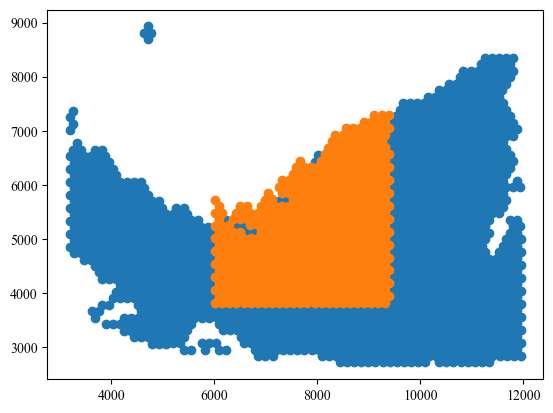

{0: array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 1: array([[ 1.00000000e+00, -3.01928839e-16,  1.32303327e+02],
        [ 2.95110819e-16,  1.00000000e+00, -3.87172572e+02],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])}

In [2]:
dst_id = 0
pyramidal_label_id = [1,2]
src_id_list = list(range(0, 2))

M = get_transform(adata_list, dst_id, src_id_list, pyramidal_label_id,tolerance=1e-3,threshold=100)
M

[[1.0215e+04 4.4990e+03 9.6750e+03 ... 5.2560e+03 5.0540e+03 6.7170e+03]
 [8.7030e+03 9.7670e+03 4.3900e+03 ... 9.8890e+03 8.0920e+03 3.5440e+03]
 [1.0000e+00 1.0000e+00 1.0000e+00 ... 1.0000e+00 1.0000e+00 1.0000e+00]]
['Layer_5' 'Layer_6' 'Layer_3' ... 'Layer_6' 'Layer_6' 'Layer_3']
0.5352428393524284


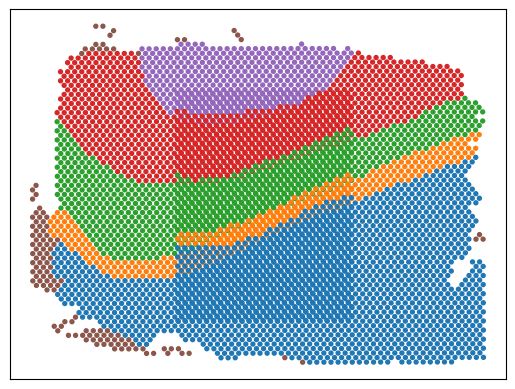

In [ ]:
coor_list = [coor_transform(adata_list[src_id].obsm['spatial'], M[src_id]) for src_id in src_id_list]
label_list = [adata_list[src_id].obs['cluster'].to_numpy() for src_id in src_id_list]
print(coor_list[0])
print(label_list[0])




plotting(coor_list, label_list, spot_size=8)
score= calculate_alignment_score(coor_list, label_list, knears=1)
print (score)

In [15]:
import numpy as np
from scipy.spatial import cKDTree
def evaluation(src_cor, tgt_cor, src_exp, tgt_exp, src_cell_type, tgt_cell_type):

    kd_tree = cKDTree(src_cor)
    distances, indices = kd_tree.query(tgt_cor, k=1)
    if hasattr(src_exp, 'toarray'):
        src_exp = src_exp.toarray()
    if hasattr(tgt_exp, 'toarray'):
        tgt_exp = tgt_exp.toarray()
    corr = np.corrcoef(np.concatenate((tgt_exp, src_exp[indices]), axis=0))[:tgt_exp.shape[0], tgt_exp.shape[0]:]
    acc = corr.trace() / tgt_exp.shape[0]
    cri = np.mean((tgt_cell_type == src_cell_type[indices]) + 0)

    return acc, cri

In [8]:
adata1=adatas[str(0) == adatas.obs['batch']]
adata2=adatas[str(1) == adatas.obs['batch']]
#adata1 = simulate_stitching(train_ad1, axis=0, from_low=True, threshold=0.1)
#adata2 = simulate_stitching(train_ad2, axis=0, from_low=False, threshold=0.1)
train_ad1_part_overlap_index = adata1.obsm['spatial'][:,0] < np.max(adata2.obsm['spatial'][:,0])
train_ad2_part_overlap_index = adata2.obsm['spatial'][:,0] > np.min(adata1.obsm['spatial'][:,0])
adata1.obsm['align_spatial'] = coor_list[0].T
src_overlap = adata1[train_ad1_part_overlap_index,:]
tgt_overlap = adata2[train_ad2_part_overlap_index,:]

In [17]:
pcc_median, cri=evaluation(coor_list[0].T, coor_list[1].T, adatas[str(0) == adatas.obs['batch']].X, adatas[str(1) == adatas.obs['batch']].X, np.array(label_list[0]), np.array(label_list[1]))

In [18]:
pcc_median

0.5811746270331892

In [23]:
cri

0.8823529411764706